# IMPORTS

In [1]:
import logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s') # NOTSET, DEBUG, INFO, WARN, ERROR, CRITICAL

import os, sys
import torch
import numpy as np

import CL_inference as cl_inference
N_threads = cl_inference.train_tools.set_N_threads_(N_threads=1)
torch.set_num_threads(N_threads)
torch.set_num_interop_threads(N_threads)
device = cl_inference.train_tools.set_torch_device_()

%load_ext autoreload

import matplotlib as mpl
import matplotlib.pyplot as plt
%matplotlib notebook
plt.style.use('default')
plt.close('all')
font, rcnew = cl_inference.plot_utils.matplotlib_default_config()
mpl.rc('font', **font)
plt.rcParams.update(rcnew)
plt.style.use('tableau-colorblind10')
%config InlineBackend.figure_format = 'retina'

2024-08-09 18:17:28,426 - INFO - N_threads: 1
2024-08-09 18:17:28,479 - INFO - Device: cuda


In [2]:
tmp_CL = "Wein"

tmp_dataset_str = "eagle_bahamas"
# all
# v1_v2, v1_v3, v2_v3
# f0_f1, f2_f3, f4_f5, f6_f7, f8_f9
# illustris_eagle, bahamas_illustris, eagle_bahamas

<IPython.core.display.Javascript object>

2024-08-09 18:17:29,582 - WARNING - Not value for keywandb_version in sweepy-sweep-27


<IPython.core.display.Javascript object>


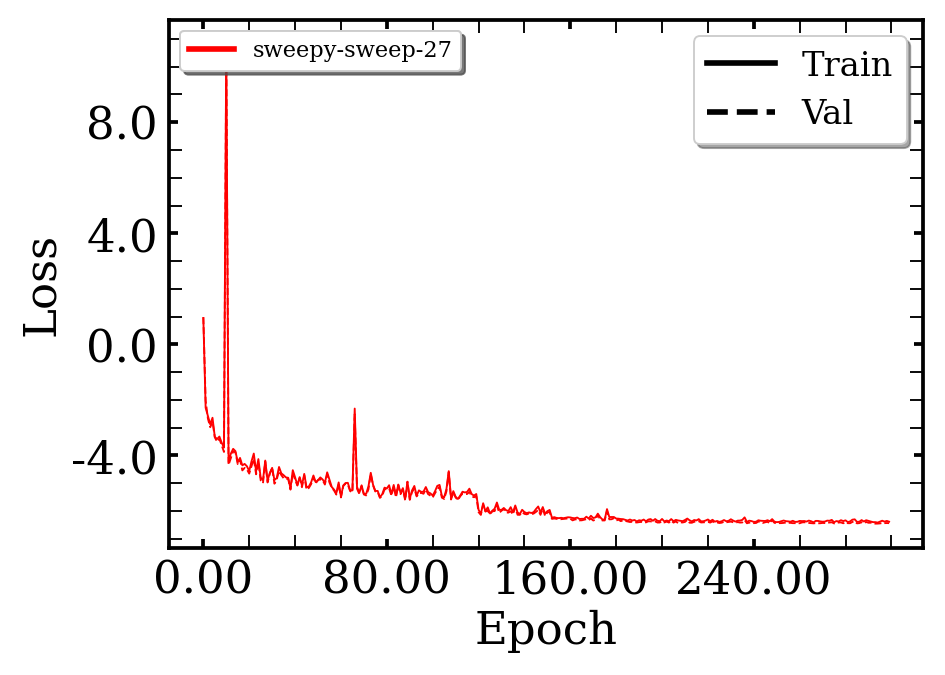

2024-08-09 18:17:29,959 - INFO - Loaded model encoder: sweepy-sweep-27
2024-08-09 18:17:29,976 - INFO - Loaded model inference: sweepy-sweep-27


In [3]:
models_path = '/cosmos_storage/home/dlopez/Projects/CL_inference/models/only_inference_models_'+tmp_dataset_str+'_kmax_0.6'
# models_path = '/cosmos_storage/home/dlopez/Projects/CL_inference/models/only_inference_CL_'+tmp_CL+'_models_'+tmp_dataset_str+'_kmax_0.6'

configs = cl_inference.plot_utils.get_config_files(models_path, select_N_best_runs=1, wandb_entity="daniellopezcano")

# evalute_mode = 'eval_CL' # "eval_CL", "eval_CL_and_inference", "eval_inference_supervised"
if "only_CL" in models_path:
    evalute_mode = 'eval_CL'
else:
    evalute_mode = 'eval_CL_and_inference'
models_encoder, models_inference = cl_inference.evaluation_tools.reload_models(models_path, evalute_mode, configs, device)

In [4]:
model_name_broadest = "Model_vary_all"
dset_name = "TEST"

key0_dset = list(configs.keys())[0]
sweep_name_load_norm_dset = key0_dset
save_root = configs[key0_dset]["path_save"]
config = configs[sweep_name_load_norm_dset]

list_model_names = [model_name_broadest] + config["list_model_names"]

In [5]:
try:
    print("include_baryon_params:", config['include_baryon_params'])
except:
    config['include_baryon_params'] = False
include_baryon_params = config['include_baryon_params']

try:
    print("dset_type:", config['dset_type'])
except:
    config['dset_type'] = "baccoemu"
dset_type = config['dset_type']

try:
    print("dset_dict:", config['dset_dict'])
except:
    config['dset_dict'] = {
        "add_noise_Pk" : "cosmic_var_gauss",
        "kmax"         : 0.6
    }
    try:
        print("box:", config['box'])
        config['dset_dict'].update({'box' : config['box']})
    except:
        config['dset_dict'].update({'box' : 2000})
    try:
        print("factor_kmin_cut:", config['factor_kmin_cut'])
        config['dset_dict'].update({'factor_kmin_cut' : config['factor_kmin_cut']})
    except:
        config['dset_dict'].update({'factor_kmin_cut' : 4})

In [6]:
custom_titles, limits_plots_inference, list_range_priors, xx_domain, colors, thresholds_bias, NN_bins_hist_bias, NN_bins_hist_err, NN_avail_cosmo_test, NN_split, max_err_hist = cl_inference.plot_utils.get_titles_limits_priors_and_colors_dset_models(
    dset_type             = config['dset_type'],
    dset_dict             = config['dset_dict'],
    list_model_names      = list_model_names,
    include_baryon_params = config['include_baryon_params']
)

In [7]:
dsets = {}
dsets[dset_name], len_models = cl_inference.data_tools.def_data_loader(
    path_load             = os.path.join(config['path_load'], dset_name),
    list_model_names      = list_model_names,
    dset_type             = dset_type,
    dset_dict             = config['dset_dict'],
    include_baryon_params = include_baryon_params,
    normalize             = config['normalize'],
    path_load_norm        = os.path.join(config['path_save'], sweep_name_load_norm_dset),
    NN_augs_batch         = config['NN_augs_batch'],
    return_len_models     = True
)

2024-08-09 18:17:30,045 - INFO - Defining data loader...
2024-08-09 18:17:30,046 - INFO - Loading stored data...
2024-08-09 18:17:30,046 - INFO - Loading Model_vary_all...
2024-08-09 18:17:30,081 - INFO - Loading Model_fixed_eagle...
2024-08-09 18:17:30,111 - INFO - Loading Model_fixed_bahamas...
2024-08-09 18:17:30,141 - INFO - Initializing data loader...
2024-08-09 18:17:30,142 - INFO - Loading normalization parameters...


In [8]:
NN_seed = 1000

samples_xx = np.zeros((NN_seed,) + dsets[dset_name].xx.shape)
samples_theta_pred = np.zeros((NN_seed, dsets[dset_name].theta.shape[0], dsets[dset_name].xx.shape[1], dsets[dset_name].theta.shape[-1]))
samples_Cov_pred = np.zeros((NN_seed, dsets[dset_name].theta.shape[0], dsets[dset_name].xx.shape[1], dsets[dset_name].theta.shape[-1], dsets[dset_name].theta.shape[-1]))
for ii_seed in range(NN_seed):
    xx, hh, theta_true, theta_pred, Cov, len_models = cl_inference.evaluation_tools.compute_dataset_results(
        config,
        sweep_name_load_norm_dset,
        list_model_names=list_model_names,
        models_encoder=models_encoder,
        models_inference=models_inference,
        dset_key="TEST",
        use_all_dataset_augs_ordered=True,
        seed=ii_seed
    )
    samples_xx[ii_seed] = xx
    samples_theta_pred[ii_seed] = theta_pred
    samples_Cov_pred[ii_seed] = Cov

2024-08-09 18:17:30,205 - INFO - Defining data loader...
2024-08-09 18:17:30,206 - INFO - Loading stored data...
2024-08-09 18:17:30,207 - INFO - Loading Model_vary_all...
2024-08-09 18:17:30,237 - INFO - Loading Model_fixed_eagle...
2024-08-09 18:17:30,266 - INFO - Loading Model_fixed_bahamas...
2024-08-09 18:17:30,300 - INFO - Initializing data loader...
2024-08-09 18:17:30,301 - INFO - Loading normalization parameters...
2024-08-09 18:17:31,245 - INFO - Defining data loader...
2024-08-09 18:17:31,246 - INFO - Loading stored data...
2024-08-09 18:17:31,247 - INFO - Loading Model_vary_all...
2024-08-09 18:17:31,278 - INFO - Loading Model_fixed_eagle...
2024-08-09 18:17:31,306 - INFO - Loading Model_fixed_bahamas...
2024-08-09 18:17:31,338 - INFO - Initializing data loader...
2024-08-09 18:17:31,339 - INFO - Loading normalization parameters...
2024-08-09 18:17:31,989 - INFO - Defining data loader...
2024-08-09 18:17:31,990 - INFO - Loading stored data...
2024-08-09 18:17:31,991 - INFO 

2024-08-09 18:17:44,205 - INFO - Loading Model_vary_all...
2024-08-09 18:17:44,224 - INFO - Loading Model_fixed_eagle...
2024-08-09 18:17:44,255 - INFO - Loading Model_fixed_bahamas...
2024-08-09 18:17:44,278 - INFO - Initializing data loader...
2024-08-09 18:17:44,279 - INFO - Loading normalization parameters...
2024-08-09 18:17:44,940 - INFO - Defining data loader...
2024-08-09 18:17:44,941 - INFO - Loading stored data...
2024-08-09 18:17:44,941 - INFO - Loading Model_vary_all...
2024-08-09 18:17:44,959 - INFO - Loading Model_fixed_eagle...
2024-08-09 18:17:44,987 - INFO - Loading Model_fixed_bahamas...
2024-08-09 18:17:45,008 - INFO - Initializing data loader...
2024-08-09 18:17:45,009 - INFO - Loading normalization parameters...
2024-08-09 18:17:45,650 - INFO - Defining data loader...
2024-08-09 18:17:45,652 - INFO - Loading stored data...
2024-08-09 18:17:45,652 - INFO - Loading Model_vary_all...
2024-08-09 18:17:45,672 - INFO - Loading Model_fixed_eagle...
2024-08-09 18:17:45,686

2024-08-09 18:17:57,788 - INFO - Loading stored data...
2024-08-09 18:17:57,789 - INFO - Loading Model_vary_all...
2024-08-09 18:17:57,806 - INFO - Loading Model_fixed_eagle...
2024-08-09 18:17:57,834 - INFO - Loading Model_fixed_bahamas...
2024-08-09 18:17:57,854 - INFO - Initializing data loader...
2024-08-09 18:17:57,855 - INFO - Loading normalization parameters...
2024-08-09 18:17:58,470 - INFO - Defining data loader...
2024-08-09 18:17:58,471 - INFO - Loading stored data...
2024-08-09 18:17:58,471 - INFO - Loading Model_vary_all...
2024-08-09 18:17:58,491 - INFO - Loading Model_fixed_eagle...
2024-08-09 18:17:58,505 - INFO - Loading Model_fixed_bahamas...
2024-08-09 18:17:58,522 - INFO - Initializing data loader...
2024-08-09 18:17:58,523 - INFO - Loading normalization parameters...
2024-08-09 18:17:59,123 - INFO - Defining data loader...
2024-08-09 18:17:59,124 - INFO - Loading stored data...
2024-08-09 18:17:59,125 - INFO - Loading Model_vary_all...
2024-08-09 18:17:59,144 - INF

2024-08-09 18:18:10,987 - INFO - Loading Model_fixed_eagle...
2024-08-09 18:18:11,001 - INFO - Loading Model_fixed_bahamas...
2024-08-09 18:18:11,018 - INFO - Initializing data loader...
2024-08-09 18:18:11,019 - INFO - Loading normalization parameters...
2024-08-09 18:18:11,613 - INFO - Defining data loader...
2024-08-09 18:18:11,614 - INFO - Loading stored data...
2024-08-09 18:18:11,615 - INFO - Loading Model_vary_all...
2024-08-09 18:18:11,632 - INFO - Loading Model_fixed_eagle...
2024-08-09 18:18:11,659 - INFO - Loading Model_fixed_bahamas...
2024-08-09 18:18:11,680 - INFO - Initializing data loader...
2024-08-09 18:18:11,681 - INFO - Loading normalization parameters...
2024-08-09 18:18:12,288 - INFO - Defining data loader...
2024-08-09 18:18:12,290 - INFO - Loading stored data...
2024-08-09 18:18:12,290 - INFO - Loading Model_vary_all...
2024-08-09 18:18:12,308 - INFO - Loading Model_fixed_eagle...
2024-08-09 18:18:12,321 - INFO - Loading Model_fixed_bahamas...
2024-08-09 18:18:1

2024-08-09 18:18:23,781 - INFO - Loading Model_fixed_bahamas...
2024-08-09 18:18:23,801 - INFO - Initializing data loader...
2024-08-09 18:18:23,802 - INFO - Loading normalization parameters...
2024-08-09 18:18:24,413 - INFO - Defining data loader...
2024-08-09 18:18:24,414 - INFO - Loading stored data...
2024-08-09 18:18:24,414 - INFO - Loading Model_vary_all...
2024-08-09 18:18:24,431 - INFO - Loading Model_fixed_eagle...
2024-08-09 18:18:24,444 - INFO - Loading Model_fixed_bahamas...
2024-08-09 18:18:24,462 - INFO - Initializing data loader...
2024-08-09 18:18:24,463 - INFO - Loading normalization parameters...
2024-08-09 18:18:25,051 - INFO - Defining data loader...
2024-08-09 18:18:25,053 - INFO - Loading stored data...
2024-08-09 18:18:25,053 - INFO - Loading Model_vary_all...
2024-08-09 18:18:25,070 - INFO - Loading Model_fixed_eagle...
2024-08-09 18:18:25,096 - INFO - Loading Model_fixed_bahamas...
2024-08-09 18:18:25,116 - INFO - Initializing data loader...
2024-08-09 18:18:25

...

2024-08-09 18:27:32,219 - INFO - Loading normalization parameters...
2024-08-09 18:27:32,778 - INFO - Defining data loader...
2024-08-09 18:27:32,779 - INFO - Loading stored data...
2024-08-09 18:27:32,780 - INFO - Loading Model_vary_all...
2024-08-09 18:27:32,797 - INFO - Loading Model_fixed_eagle...
2024-08-09 18:27:32,824 - INFO - Loading Model_fixed_bahamas...
2024-08-09 18:27:32,843 - INFO - Initializing data loader...
2024-08-09 18:27:32,844 - INFO - Loading normalization parameters...
2024-08-09 18:27:33,414 - INFO - Defining data loader...
2024-08-09 18:27:33,415 - INFO - Loading stored data...
2024-08-09 18:27:33,416 - INFO - Loading Model_vary_all...
2024-08-09 18:27:33,432 - INFO - Loading Model_fixed_eagle...
2024-08-09 18:27:33,458 - INFO - Loading Model_fixed_bahamas...
2024-08-09 18:27:33,477 - INFO - Initializing data loader...
2024-08-09 18:27:33,478 - INFO - Loading normalization parameters...
2024-08-09 18:27:34,060 - INFO - Defining data loader...
2024-08-09 18:27:3

2024-08-09 18:27:44,866 - INFO - Initializing data loader...
2024-08-09 18:27:44,867 - INFO - Loading normalization parameters...
2024-08-09 18:27:45,457 - INFO - Defining data loader...
2024-08-09 18:27:45,458 - INFO - Loading stored data...
2024-08-09 18:27:45,458 - INFO - Loading Model_vary_all...
2024-08-09 18:27:45,475 - INFO - Loading Model_fixed_eagle...
2024-08-09 18:27:45,488 - INFO - Loading Model_fixed_bahamas...
2024-08-09 18:27:45,504 - INFO - Initializing data loader...
2024-08-09 18:27:45,504 - INFO - Loading normalization parameters...
2024-08-09 18:27:46,073 - INFO - Defining data loader...
2024-08-09 18:27:46,074 - INFO - Loading stored data...
2024-08-09 18:27:46,075 - INFO - Loading Model_vary_all...
2024-08-09 18:27:46,091 - INFO - Loading Model_fixed_eagle...
2024-08-09 18:27:46,118 - INFO - Loading Model_fixed_bahamas...
2024-08-09 18:27:46,136 - INFO - Initializing data loader...
2024-08-09 18:27:46,137 - INFO - Loading normalization parameters...
2024-08-09 18:

2024-08-09 18:27:57,205 - INFO - Loading normalization parameters...
2024-08-09 18:27:57,791 - INFO - Defining data loader...
2024-08-09 18:27:57,792 - INFO - Loading stored data...
2024-08-09 18:27:57,793 - INFO - Loading Model_vary_all...
2024-08-09 18:27:57,809 - INFO - Loading Model_fixed_eagle...
2024-08-09 18:27:57,835 - INFO - Loading Model_fixed_bahamas...
2024-08-09 18:27:57,854 - INFO - Initializing data loader...
2024-08-09 18:27:57,855 - INFO - Loading normalization parameters...
2024-08-09 18:27:58,449 - INFO - Defining data loader...
2024-08-09 18:27:58,450 - INFO - Loading stored data...
2024-08-09 18:27:58,450 - INFO - Loading Model_vary_all...
2024-08-09 18:27:58,467 - INFO - Loading Model_fixed_eagle...
2024-08-09 18:27:58,493 - INFO - Loading Model_fixed_bahamas...
2024-08-09 18:27:58,512 - INFO - Initializing data loader...
2024-08-09 18:27:58,513 - INFO - Loading normalization parameters...
2024-08-09 18:27:59,111 - INFO - Defining data loader...
2024-08-09 18:27:5

2024-08-09 18:28:10,196 - INFO - Defining data loader...
2024-08-09 18:28:10,197 - INFO - Loading stored data...
2024-08-09 18:28:10,198 - INFO - Loading Model_vary_all...
2024-08-09 18:28:10,214 - INFO - Loading Model_fixed_eagle...
2024-08-09 18:28:10,241 - INFO - Loading Model_fixed_bahamas...
2024-08-09 18:28:10,262 - INFO - Initializing data loader...
2024-08-09 18:28:10,263 - INFO - Loading normalization parameters...
2024-08-09 18:28:10,880 - INFO - Defining data loader...
2024-08-09 18:28:10,881 - INFO - Loading stored data...
2024-08-09 18:28:10,882 - INFO - Loading Model_vary_all...
2024-08-09 18:28:10,899 - INFO - Loading Model_fixed_eagle...
2024-08-09 18:28:10,926 - INFO - Loading Model_fixed_bahamas...
2024-08-09 18:28:10,947 - INFO - Initializing data loader...
2024-08-09 18:28:10,948 - INFO - Loading normalization parameters...
2024-08-09 18:28:11,534 - INFO - Defining data loader...
2024-08-09 18:28:11,535 - INFO - Loading stored data...
2024-08-09 18:28:11,536 - INFO 

2024-08-09 18:28:22,674 - INFO - Loading Model_vary_all...
2024-08-09 18:28:22,691 - INFO - Loading Model_fixed_eagle...
2024-08-09 18:28:22,717 - INFO - Loading Model_fixed_bahamas...
2024-08-09 18:28:22,735 - INFO - Initializing data loader...
2024-08-09 18:28:22,736 - INFO - Loading normalization parameters...
2024-08-09 18:28:23,339 - INFO - Defining data loader...
2024-08-09 18:28:23,340 - INFO - Loading stored data...
2024-08-09 18:28:23,340 - INFO - Loading Model_vary_all...
2024-08-09 18:28:23,358 - INFO - Loading Model_fixed_eagle...
2024-08-09 18:28:23,384 - INFO - Loading Model_fixed_bahamas...
2024-08-09 18:28:23,402 - INFO - Initializing data loader...
2024-08-09 18:28:23,403 - INFO - Loading normalization parameters...
2024-08-09 18:28:23,985 - INFO - Defining data loader...
2024-08-09 18:28:23,986 - INFO - Loading stored data...
2024-08-09 18:28:23,986 - INFO - Loading Model_vary_all...
2024-08-09 18:28:24,003 - INFO - Loading Model_fixed_eagle...
2024-08-09 18:28:24,029

<IPython.core.display.Javascript object>


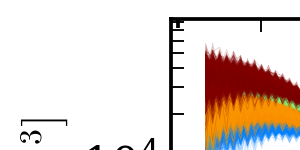

In [9]:
NN_plot = 5
# indexes_cosmos = np.random.choice(samples_xx.shape[1], NN_plot, replace=False)
indexes_cosmos = np.arange(NN_plot)
ii_aug = 0

fig, ax = cl_inference.plot_utils.simple_plot()
ax.set_ylabel(r'$P(k) \left[ \left(h^{-1} \mathrm{Mpc}\right)^{3} \right]$')
ax.set_xlabel(r'$\mathrm{Wavenumber}\, k \left[ h\, \mathrm{Mpc}^{-1} \right]$')
ax.set_xscale('log')
ax.set_yscale('log')

colors = cl_inference.plot_utils.get_N_colors(NN_plot, mpl.colormaps['jet'])
for ii_cosmo, index_cosmo in enumerate(indexes_cosmos):
    xx_plot = samples_xx[:, index_cosmo, ii_aug]
    dset_norm_std = dsets[dset_name].norm_std
    dset_norm_mean = dsets[dset_name].norm_mean

    xx_plot = 10**(xx_plot*dset_norm_std + dset_norm_mean)
    ax.plot(xx_domain, xx_plot.T, c=colors[ii_cosmo], lw=0.4, alpha=0.2)

fig.set_tight_layout(True)

<IPython.core.display.Javascript object>


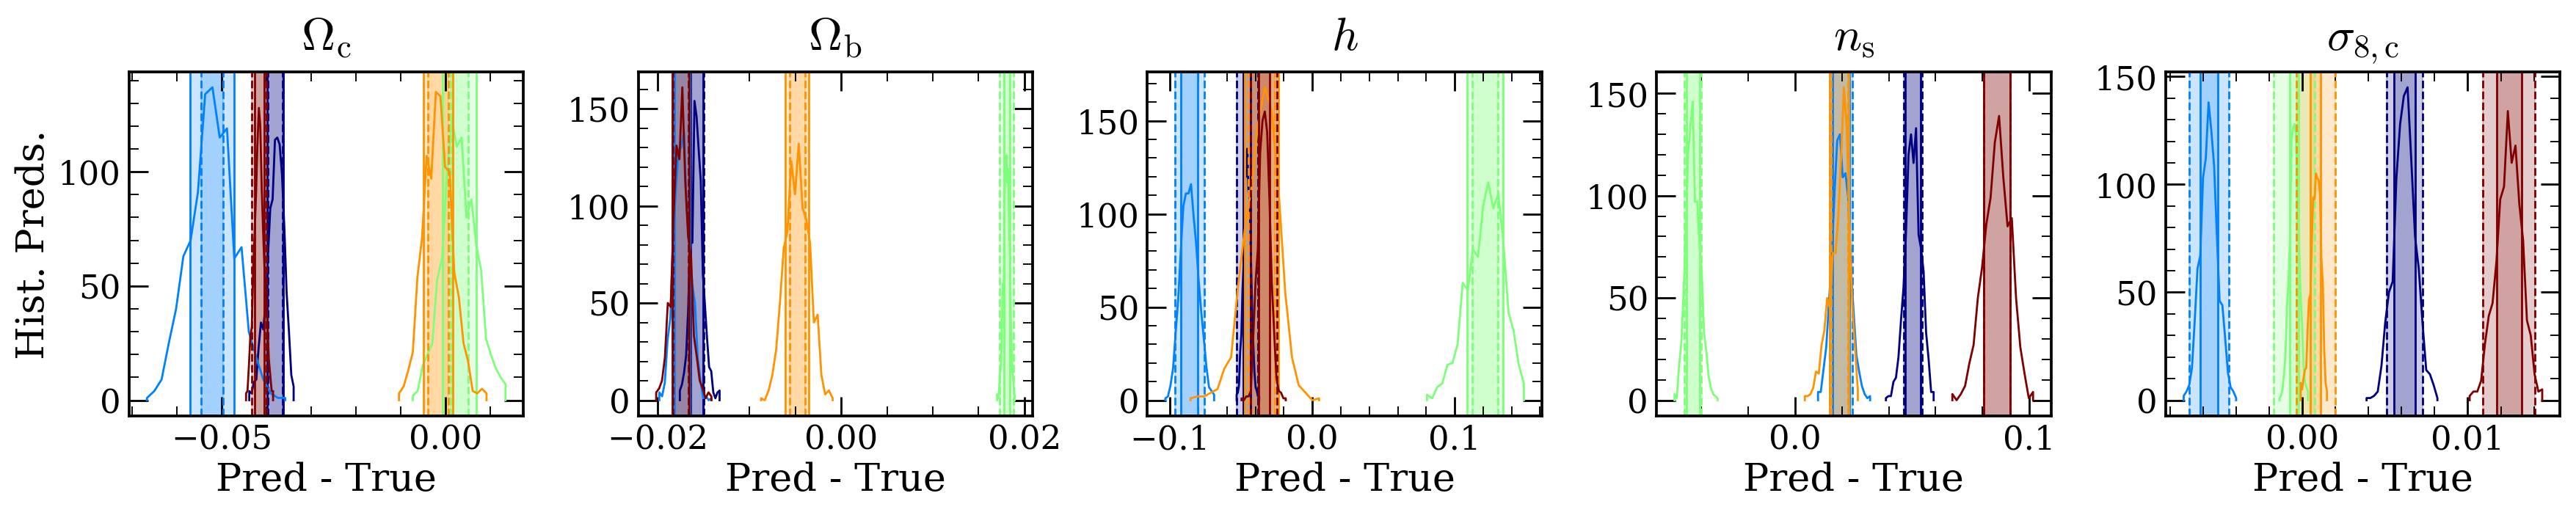

In [12]:
Nbins = 20

fontsize=26
fontsize1=18
fig, axs = plt.subplots(1, len(custom_titles), figsize=(5.2*len(custom_titles), 5.2))
axs[0].set_ylabel(r'Hist. Preds.')

for ii_cosmo in range(len(custom_titles)):
    ax = axs[ii_cosmo]
    ax.set_title(custom_titles[ii_cosmo], size=fontsize+8, pad=16)
    ax.set_xlabel(r'Pred - True')
    for ii_selected_cosmo, index_cosmo in enumerate(indexes_cosmos):
        tmp_hist = samples_theta_pred[:,index_cosmo, ii_aug, ii_cosmo] - np.repeat(theta_true[index_cosmo, ii_aug, ii_cosmo], NN_seed)
        min_hist = np.nanmin(tmp_hist)
        max_hist = np.nanmax(tmp_hist)
        counts, bin_edges = np.histogram(tmp_hist, bins=Nbins, range=(min_hist, max_hist))
        counts = np.insert(counts, 0, np.sum(tmp_hist<min_hist), axis=0)
        counts = np.insert(counts, len(counts), np.sum(tmp_hist>max_hist), axis=0)
        tmp_bin_centers = (bin_edges[1:] + bin_edges[:-1])/2
        tmp_bin_centers = np.insert(tmp_bin_centers, 0, tmp_bin_centers[..., 0], axis=-1)
        tmp_bin_centers = np.insert(tmp_bin_centers, tmp_bin_centers.shape[-1], tmp_bin_centers[..., -1], axis=-1)
        
        ax.plot(tmp_bin_centers, counts, c=colors[ii_selected_cosmo], lw=1.5)
        
        ax.axvline(np.mean(tmp_hist)-np.std(tmp_hist), c=colors[ii_selected_cosmo], lw=1.5, ls='-')
        ax.axvline(np.mean(tmp_hist)+np.std(tmp_hist), c=colors[ii_selected_cosmo], lw=1.5, ls='-')
        ax.axvspan(np.mean(tmp_hist)-np.std(tmp_hist), np.mean(tmp_hist)+np.std(tmp_hist), alpha=0.2, color=colors[ii_selected_cosmo])
        
        tmp_std = np.sqrt(np.mean(samples_Cov_pred[:,index_cosmo, ii_aug, ii_cosmo, ii_cosmo]))
        ax.axvline(np.mean(tmp_hist)-tmp_std/2, c=colors[ii_selected_cosmo], lw=1.5, ls='--')
        ax.axvline(np.mean(tmp_hist)+tmp_std/2, c=colors[ii_selected_cosmo], lw=1.5, ls='--')
        ax.axvspan(np.mean(tmp_hist)-tmp_std/2, np.mean(tmp_hist)+tmp_std/2, alpha=0.2, color=colors[ii_selected_cosmo])
        
fig.set_tight_layout(True)